# Trabajo integrador final

Curso Herramientas Básicas en Ciencia de Datos - UTN

## Contexto

El índice de readmisiones hospitalarias posteriores a procedimientos quirúrgicos es uno de los parámetros que más influye en los costos de gestión y uno de los más demandantes en recursos institucionales.

Como referencia, puede señalarse su presencia en sistemas de salud tan diversos como Medicare en Estados Unidos y PAMI en Argentina, donde existen mecanismos de penalización o débitos vinculados a estas readmisiones. En algunos casos, esto puede hacer que no solo no generen ganancias, sino que incluso deriven en pérdidas económicas importantes y en complicaciones logísticas y de gestión superiores a las de los procedimientos primarios. Identificar los procedimientos con mayor ingerencia en estos parametros de readmision y costos, es de vital importancia en la administracion economica de un centro de salud.

Su análisis motiva el siguiente proyecto.

Los dataset de salud reales se encuentran restringidos por politicas de privacidad , por lo tanto se utilizo en dataset ficticio que respetaria parametros standard para un hospital de considerables
dimensiones.


 Fuente directa

https://mavenanalytics.io/challenges/maven-hospital-challenge

## Pregunta de investigación

¿Qué procedimientos quirúrgicos asociados a readmisiones dentro de los 30 días presentan costos y utilización de recursos hospitalarios superiores al promedio de los procedimientos primarios?

## Hipótesis

Se espera que algunos procedimientos quirúrgicos asociados a readmisiones dentro de los 30 días presenten costos y utilización de recursos hospitalarios superiores al promedio de los procedimientos primarios.

## Aclaración metodológica

En este trabajo, la utilización de recursos hospitalarios se analizará a partir de indicadores como el costo de atención, la frecuencia de readmisiones y otras variables operativas del dataset vinculadas al uso de servicios.

# Diccionario de datos

## procedures

- **PATIENT**: relaciona cada paciente con su respectivo procedimiento.
- **ENCOUNTER**: define la atención en la que se realizó el procedimiento. Me permite unir esta tabla con `encounters`.
- **DESCRIPTION**: describe el procedimiento realizado. Desde esta variable voy a seleccionar los procedimientos quirúrgicos.
- **BASE_COST**: nos muestra el costo base del procedimiento. La voy a usar para comparar el peso económico de distintos procedimientos.

## encounters

- **Id**: muestra el código de cada atención. Sirve para relacionar esta tabla con `procedures`.
- **PATIENT**: señala qué paciente recibió esa atención. Me permite seguir la secuencia de atenciones de una misma persona.
- **START**: fecha de inicio de la atención. Se usa para ordenar los registros en el tiempo.
- **STOP**: fecha de finalización de la atención. es fundamental para para calcular si hubo otra atención dentro de los 30 días.
- **TOTAL_CLAIM_COST**: nos muestra el costo total de la atención. Se usa como referencia principal en el análisis económico.

## patients

- **Id**:  muestra el código de cada paciente. Se usa para vincular esta tabla con las demás.
- **BIRTHDATE**: Puede servir si después necesito calcular edad.
- **GENDER**: sexo del paciente. algunos procedimientos son privativos de un genero protatectomia, histerectomia por ejemplo.

## Importación de librerías y carga de datos

In [ ]:
# Importación de librerías
import pandas as pd

In [ ]:
# Importación de herramienta para cargar archivos
from google.colab import files

In [ ]:
# Conexión con Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Ubicación de la carpeta de trabajo
import os

In [ ]:
# Ruta del archivo comprimido en Google Drive
ruta_zip = "/content/drive/MyDrive/Hospital+Patient+Records (1).zip"

In [ ]:
# Descompresión del archivo zip
import zipfile

with zipfile.ZipFile(ruta_zip, 'r') as zip_ref:
    zip_ref.extractall('/content/hospital_dataset')

In [ ]:
# Listado de archivos descomprimidos
import os
os.listdir('/content/hospital_dataset')

['data_dictionary.csv',
 'hospital_analytics_questions.sql',
 'encounters.csv',
 'organizations.csv',
 'procedures.csv',
 'citation.txt',
 'payers.csv',
 'create_hospital_db.sql',
 'patients.csv']

In [ ]:
# Carga de la tabla encounters
encounters = pd.read_csv('/content/hospital_dataset/encounters.csv')

In [ ]:
# Carga de la tabla procedures
procedures = pd.read_csv('/content/hospital_dataset/procedures.csv')

In [ ]:
# Carga de la tabla patients
patients = pd.read_csv('/content/hospital_dataset/patients.csv')

In [ ]:
# Vista inicial de la tabla patients
patients.head()

,Id,BIRTHDATE,DEATHDATE,PREFIX,FIRST,LAST,SUFFIX,MAIDEN,MARITAL,RACE,ETHNICITY,GENDER,BIRTHPLACE,ADDRESS,CITY,STATE,COUNTY,ZIP,LAT,LON
0,5605b66b-e92d-c16c-1b83-b8bf7040d51f,1977-03-19,NaN,Mrs.,Nikita578,Erdman779,NaN,Leannon79,M,white,nonhispanic,F,Wakefield Massachusetts US,510 Little Station Unit 69,Quincy,Massachusetts,Norfolk County,2186.0,42.290937,-70.975503
1,6e5ae27c-8038-7988-e2c0-25a103f01bfa,1940-02-19,NaN,Mr.,Zane918,Hodkiewicz467,NaN,NaN,M,white,nonhispanic,M,Brookline Massachusetts US,747 Conn Throughway,Boston,Massachusetts,Suffolk County,2135.0,42.308831,-71.063162
2,8123d076-0886-9007-e956-d5864aa121a7,1958-06-04,NaN,Mr.,Quinn173,Marquardt819,NaN,NaN,M,white,nonhispanic,M,Gardner Massachusetts US,816 Okuneva Extension Apt 91,Quincy,Massachusetts,Norfolk County,2170.0,42.265177,-70.967085
3,770518e4-6133-648e-60c9-071eb2f0e2ce,1928-12-25,2017-09-29,Mr.,Abel832,Smitham825,NaN,NaN,M,white,hispanic,M,Randolph Massachusetts US,127 Cole Way Unit 95,Boston,Massachusetts,Suffolk County,2118.0,42.334304,-71.066801
4,f96addf5-81b9-0aab-7855-d208d3d352c5,1928-12-25,2014-02-23,Mr.,Edwin773,Labadie908,NaN,NaN,M,white,hispanic,M,Stow Massachusetts US,976 Ziemann Gateway,Boston,Massachusetts,Suffolk County,2125.0,42.346771,-71.058813


In [ ]:
# Carga de la tabla encounters
encounters = pd.read_csv('/content/hospital_dataset/encounters.csv')

In [ ]:
# Vista inicial de la tabla encounters
encounters.head()

,Id,START,STOP,PATIENT,ORGANIZATION,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,REASONCODE,REASONDESCRIPTION
0,32c84703-2481-49cd-d571-3899d5820253,2011-01-02T09:26:36Z,2011-01-02T12:58:36Z,3de74169-7f67-9304-91d4-757e0f3a14d2,d78e84ec-30aa-3bba-a33a-f29a3a454662,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,ambulatory,185347001,Encounter for problem (procedure),85.55,1018.02,0.00,NaN,NaN
1,c98059da-320a-c0a6-fced-c8815f3e3f39,2011-01-03T05:44:39Z,2011-01-03T06:01:42Z,d9ec2e44-32e9-9148-179a-1653348cc4e2,d78e84ec-30aa-3bba-a33a-f29a3a454662,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,outpatient,308335008,Patient encounter procedure,142.58,2619.36,0.00,NaN,NaN
2,4ad28a3a-2479-782b-f29c-d5b3f41a001e,2011-01-03T14:32:11Z,2011-01-03T14:47:11Z,73babadf-5b2b-fee7-189e-6f41ff213e01,d78e84ec-30aa-3bba-a33a-f29a3a454662,7caa7254-5050-3b5e-9eae-bd5ea30e809c,outpatient,185349003,Encounter for check up (procedure),85.55,461.59,305.27,NaN,NaN
3,c3f4da61-e4b4-21d5-587a-fbc89943bc19,2011-01-03T16:24:45Z,2011-01-03T16:39:45Z,3b46a0b7-0f34-9b9a-c319-ace4a1f58c0b,d78e84ec-30aa-3bba-a33a-f29a3a454662,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,wellness,162673000,General examination of patient (procedure),136.80,1784.24,0.00,NaN,NaN
4,a9183b4f-2572-72ea-54c2-b3cd038b4be7,2011-01-03T17:36:53Z,2011-01-03T17:51:53Z,fa006887-d93c-d302-8b89-f3c25f88c0e1,d78e84ec-30aa-3bba-a33a-f29a3a454662,42c4fca7-f8a9-3cd1-982a-dd9751bf3e2a,ambulatory,390906007,Follow-up encounter,85.55,234.72,0.00,55822004.0,Hyperlipidemia


In [ ]:
# Carga de la tabla procedures
procedures = pd.read_csv('/content/hospital_dataset/procedures.csv')

In [ ]:
# Vista inicial de la tabla procedures
procedures.head()

,START,STOP,PATIENT,ENCOUNTER,CODE,DESCRIPTION,BASE_COST,REASONCODE,REASONDESCRIPTION
0,2011-01-02T09:26:36Z,2011-01-02T12:58:36Z,3de74169-7f67-9304-91d4-757e0f3a14d2,32c84703-2481-49cd-d571-3899d5820253,265764009,Renal dialysis (procedure),903,NaN,NaN
1,2011-01-03T05:44:39Z,2011-01-03T06:01:42Z,d9ec2e44-32e9-9148-179a-1653348cc4e2,c98059da-320a-c0a6-fced-c8815f3e3f39,76601001,Intramuscular injection,2477,NaN,NaN
2,2011-01-04T14:49:55Z,2011-01-04T15:04:55Z,d856d6e6-4c98-e7a2-129b-44076c63d008,2cfd4ddd-ad13-fe1e-528b-15051cea2ec3,703423002,Combined chemotherapy and radiation therapy (p...,11620,363406005.0,Malignant tumor of colon
3,2011-01-05T04:02:09Z,2011-01-05T04:17:09Z,bc9d59c3-0a30-6e3b-f47d-022e4f03c8de,17966936-0878-f4db-128b-a43ae10d0878,173160006,Diagnostic fiberoptic bronchoscopy (procedure),9796,162573006.0,Suspected lung cancer (situation)
4,2011-01-05T12:58:36Z,2011-01-05T16:42:36Z,3de74169-7f67-9304-91d4-757e0f3a14d2,9de5f0b0-4ba4-ce6f-45fb-b55c202f31a5,265764009,Renal dialysis (procedure),1255,NaN,NaN


In [ ]:
# Dimensiones de la tabla patients
patients.shape

(974, 20)

In [ ]:
# Columnas de la tabla patients
patients.columns

Index(['Id', 'BIRTHDATE', 'DEATHDATE', 'PREFIX', 'FIRST', 'LAST', 'SUFFIX',
       'MAIDEN', 'MARITAL', 'RACE', 'ETHNICITY', 'GENDER', 'BIRTHPLACE',
       'ADDRESS', 'CITY', 'STATE', 'COUNTY', 'ZIP', 'LAT', 'LON'],
      dtype='object')

In [ ]:
# Dimensiones de la tabla encounters
encounters.shape

(27891, 14)

In [ ]:
# Columnas de la tabla encounters
encounters.columns

Index(['Id', 'START', 'STOP', 'PATIENT', 'ORGANIZATION', 'PAYER',
       'ENCOUNTERCLASS', 'CODE', 'DESCRIPTION', 'BASE_ENCOUNTER_COST',
       'TOTAL_CLAIM_COST', 'PAYER_COVERAGE', 'REASONCODE',
       'REASONDESCRIPTION'],
      dtype='object')

In [ ]:
# Dimensiones y columnas de la tabla procedures
print(procedures.shape)
print(procedures.columns)

(47701, 9)
Index(['START', 'STOP', 'PATIENT', 'ENCOUNTER', 'CODE', 'DESCRIPTION',
       'BASE_COST', 'REASONCODE', 'REASONDESCRIPTION'],
      dtype='object')


## Análisis exploratorio de los datos

En esta etapa se realiza una primera revisión de las tablas seleccionadas para entender mejor su estructura, reconocer las variables más importantes y detectar posibles valores faltantes o inconsistencias antes del análisis principal.

In [ ]:
# Valores faltantes en la tabla procedures
procedures.isnull().sum()

,0
START,0
STOP,0
PATIENT,0
ENCOUNTER,0
CODE,0
DESCRIPTION,0
BASE_COST,0
REASONCODE,36945
REASONDESCRIPTION,36945


Las variables `REASONCODE` y `REASONDESCRIPTION` no se utilizarán como variables centrales, ya que este trabajo busca identificar los procedimientos quirúrgicos asociados a readmisiones dentro de los 30 días, no las causas que motivaron su indicación. Además, presentan una alta cantidad de valores faltantes.

In [ ]:
# Valores faltantes en la tabla encounters
encounters.isnull().sum()

,0
Id,0
START,0
STOP,0
PATIENT,0
ORGANIZATION,0
PAYER,0
ENCOUNTERCLASS,0
CODE,0
DESCRIPTION,0
BASE_ENCOUNTER_COST,0


Al igual que en `procedures`, las variables `REASONCODE` y `REASONDESCRIPTION` no se utilizarán en el análisis, ya que no forman parte del objetivo del trabajo y además presentan una alta cantidad de valores faltantes.

In [ ]:
# Valores faltantes en la tabla patients
patients.isnull().sum()

,0
Id,0
BIRTHDATE,0
DEATHDATE,820
PREFIX,0
FIRST,0
LAST,0
SUFFIX,953
MAIDEN,588
MARITAL,1
RACE,0


En la tabla `patients` se observan valores faltantes en algunas variables secundarias, pero las variables más importantes para la descripción general de los pacientes se encuentran completas o con muy pocos faltantes.

## Selección de variables para el análisis

En esta etapa se seleccionan las variables que se utilizarán en el trabajo, priorizando aquellas que se relacionan de forma directa con el objetivo del análisis.

In [ ]:
# Selección de variables de la tabla procedures
procedures = procedures[['PATIENT', 'ENCOUNTER', 'DESCRIPTION', 'BASE_COST']]

In [ ]:
# Selección de variables de la tabla encounters
encounters = encounters[['Id', 'PATIENT', 'START', 'STOP', 'ENCOUNTERCLASS', 'TOTAL_CLAIM_COST']]

In [ ]:
# Selección de variables de la tabla patients
patients = patients[['Id', 'BIRTHDATE', 'GENDER']]

In [ ]:
# Columnas seleccionadas en las tres tablas
print(procedures.columns)
print(encounters.columns)
print(patients.columns)

Index(['PATIENT', 'ENCOUNTER', 'DESCRIPTION', 'BASE_COST'], dtype='object')
Index(['Id', 'PATIENT', 'START', 'STOP', 'ENCOUNTERCLASS', 'TOTAL_CLAIM_COST'], dtype='object')
Index(['Id', 'BIRTHDATE', 'GENDER'], dtype='object')


## Preparación de las variables principales para el desarrollo del análisis

In [ ]:
# Conversión de fechas en la tabla encounters
encounters['START'] = pd.to_datetime(encounters['START'])
encounters['STOP'] = pd.to_datetime(encounters['STOP'])

In [ ]:
# Orden de los registros por paciente y fecha de inicio
encounters = encounters.sort_values(by=['PATIENT', 'START'])

In [ ]:
# Cálculo de la siguiente atención por paciente
encounters['NEXT_START'] = encounters.groupby('PATIENT')['START'].shift(-1)

### Construcción de la secuencia temporal de atenciones

En este paso se ordenan las atenciones de cada paciente en forma cronológica y se identifica la atención siguiente. Esto permite calcular el tiempo transcurrido entre una atención y otra, base necesaria para reconocer readmisiones dentro de los 30 días.

In [ ]:
# Cálculo de días hasta la siguiente atención
encounters['DAYS_TO_NEXT'] = (encounters['NEXT_START'] - encounters['STOP']).dt.days

### Cálculo del parámetro de readmisión a 30 días

In [ ]:
# Identificación de readmisión dentro de los 30 días
encounters['READMISSION_30D'] = encounters['DAYS_TO_NEXT'].between(0, 30)

In [ ]:
# Conteo de readmisiones dentro de los 30 días
encounters['READMISSION_30D'].value_counts()

,count
READMISSION_30D,
True,16875
False,11016


In [ ]:
# Selección final de variables de encounters para el cruce
encounters = encounters[['Id', 'PATIENT', 'TOTAL_CLAIM_COST', 'READMISSION_30D']]

### Unión de tablas principales

En este paso se relacionan las tablas `procedures` y `encounters`, para que cada procedimiento quede asociado a su respectiva atención. Esto permite incorporar al análisis datos clave como el costo total de la atención y la readmisión dentro de los 30 días.

In [ ]:
# Unión de procedures con encounters
procedures = procedures.merge(
    encounters,
    left_on='ENCOUNTER',
    right_on='Id',
    how='left'
)

In [ ]:
# Vista inicial de la tabla unificada
procedures.head()

,PATIENT_x,ENCOUNTER,DESCRIPTION,BASE_COST,Id,PATIENT_y,TOTAL_CLAIM_COST,READMISSION_30D
0,3de74169-7f67-9304-91d4-757e0f3a14d2,32c84703-2481-49cd-d571-3899d5820253,Renal dialysis (procedure),903,32c84703-2481-49cd-d571-3899d5820253,3de74169-7f67-9304-91d4-757e0f3a14d2,1018.02,True
1,d9ec2e44-32e9-9148-179a-1653348cc4e2,c98059da-320a-c0a6-fced-c8815f3e3f39,Intramuscular injection,2477,c98059da-320a-c0a6-fced-c8815f3e3f39,d9ec2e44-32e9-9148-179a-1653348cc4e2,2619.36,False
2,d856d6e6-4c98-e7a2-129b-44076c63d008,2cfd4ddd-ad13-fe1e-528b-15051cea2ec3,Combined chemotherapy and radiation therapy (p...,11620,2cfd4ddd-ad13-fe1e-528b-15051cea2ec3,d856d6e6-4c98-e7a2-129b-44076c63d008,11855.19,False
3,bc9d59c3-0a30-6e3b-f47d-022e4f03c8de,17966936-0878-f4db-128b-a43ae10d0878,Diagnostic fiberoptic bronchoscopy (procedure),9796,17966936-0878-f4db-128b-a43ae10d0878,bc9d59c3-0a30-6e3b-f47d-022e4f03c8de,9881.17,True
4,3de74169-7f67-9304-91d4-757e0f3a14d2,9de5f0b0-4ba4-ce6f-45fb-b55c202f31a5,Renal dialysis (procedure),1255,9de5f0b0-4ba4-ce6f-45fb-b55c202f31a5,3de74169-7f67-9304-91d4-757e0f3a14d2,1370.79,True


In [ ]:
# Descripciones más frecuentes de procedimientos
procedures['DESCRIPTION'].value_counts().head(20)

,count
DESCRIPTION,
Assessment of health and social care needs (procedure),4596
Hospice care (regime/therapy),4098
Depression screening using Patient Health Questionnaire Two-Item score (procedure),3614
Depression screening (procedure),3614
Assessment of substance use (procedure),2906
Renal dialysis (procedure),2746
Assessment using Morse Fall Scale (procedure),2422
Assessment of anxiety (procedure),2288
Medication Reconciliation (procedure),2284


## Selección de procedimientos

Como esta base no trae una variable que marque en forma directa cuáles son los procedimientos quirúrgicos,  este paso del analisis tiene como objetivo realizar una selección usando palabras clave dentro de la columna `DESCRIPTION`.

La idea  es quedarse con un grupo de procedimientos mas representativos el cual que tenga sentido analizar dentro del trabajo.

In [ ]:
# Búsqueda de procedimientos quirúrgicos o intervencionistas
procedures[procedures['DESCRIPTION'].str.contains('surgery|surgical|colonoscopy|biopsy|ablation|cardioversion|thrombectomy|polypectomy|episiotomy', case=False, na=False)]['DESCRIPTION'].value_counts()

,count
DESCRIPTION,
Electrical cardioversion,1383
Colonoscopy,424
Catheter ablation of tissue of heart,365
Rectal polypectomy,61
Percutaneous mechanical thrombectomy of portal vein using fluoroscopic guidance,57
Episiotomy,36
Biopsy of prostate,22
Surgical manipulation of joint of knee,12
Biopsy of breast (procedure),7


In [ ]:
# Selección de procedimientos quirúrgicos
procedures_qx = procedures[
    procedures['DESCRIPTION'].str.contains(
        'colonoscopy|biopsy|ablation|cardioversion|thrombectomy|polypectomy|episiotomy|surgical',
        case=False,
        na=False
    )
]

In [ ]:
# Cantidad de registros de procedimientos quirúrgicos
procedures_qx.shape

(2374, 8)

El recorte realizado permitió obtener un subconjunto de **2374 registros** correspondientes a procedimientos quirúrgicos o intervencionistas. Este punto es importante, ya que muestra que el análisis puede sostenerse sobre una base con volumen suficiente, sin quedar limitado a unos pocos casos.

In [ ]:
# Frecuencia de los procedimientos quirúrgicos seleccionados
procedures_qx['DESCRIPTION'].value_counts()

,count
DESCRIPTION,
Electrical cardioversion,1383
Colonoscopy,424
Catheter ablation of tissue of heart,365
Rectal polypectomy,61
Percutaneous mechanical thrombectomy of portal vein using fluoroscopic guidance,57
Episiotomy,36
Biopsy of prostate,22
Surgical manipulation of joint of knee,12
Biopsy of breast (procedure),7


## Análisis de procedimientos quirúrgicos, readmisiones y costos

In [ ]:
# Procedimientos quirúrgicos con readmisión dentro de los 30 días
procedures_qx[procedures_qx['READMISSION_30D'] == True]['DESCRIPTION'].value_counts()

,count
DESCRIPTION,
Electrical cardioversion,967
Catheter ablation of tissue of heart,230
Colonoscopy,82
Rectal polypectomy,22
Biopsy of prostate,17
Percutaneous mechanical thrombectomy of portal vein using fluoroscopic guidance,14
Sentinel lymph node biopsy (procedure),4
Biopsy of breast (procedure),4
Episiotomy,3


In [ ]:
# Tasa de readmisión a 30 días por procedimiento quirúrgico
procedures_qx.groupby('DESCRIPTION')['READMISSION_30D'].mean().sort_values(ascending=False)

,READMISSION_30D
DESCRIPTION,
Biopsy of colon,1.000000
Fine needle aspiration biopsy of lung (procedure),1.000000
Sentinel lymph node biopsy (procedure),1.000000
Biopsy of prostate,0.772727
Electrical cardioversion,0.699205
Catheter ablation of tissue of heart,0.630137
Biopsy of breast (procedure),0.571429
Rectal polypectomy,0.360656
Percutaneous mechanical thrombectomy of portal vein using fluoroscopic guidance,0.245614


In [ ]:
# Cantidad total de casos por procedimiento quirúrgico
total_casos = procedures_qx['DESCRIPTION'].value_counts()

In [ ]:
# Cantidad de readmisiones a 30 días por procedimiento quirúrgico
readmisiones_30d = procedures_qx[procedures_qx['READMISSION_30D'] == True]['DESCRIPTION'].value_counts()

In [ ]:
# Cálculo de la tasa de readmisión por procedimiento quirúrgico
tasa_readmision_30d = readmisiones_30d / total_casos# Cálculo de la tasa de readmisión por procedimiento quirúrgico
tasa_readmision_30d = readmisiones_30d / total_casos

En este punto se nuclean los resultados en una sola tabla para facilitar su análisis.

In [ ]:
# Unión de los resultados en una sola tabla
resumen_qx = pd.DataFrame({
    'total_casos': total_casos,
    'readmisiones_30d': readmisiones_30d,
    'tasa_readmision_30d': tasa_readmision_30d
})

In [ ]:
# Reemplazo de valores faltantes por cero
resumen_qx = resumen_qx.fillna(0)

In [ ]:
# Orden de la tabla resumen según la tasa de readmisión
resumen_qx = resumen_qx.sort_values(by='tasa_readmision_30d', ascending=False)

In [ ]:
# Vista de la tabla resumen
resumen_qx

,total_casos,readmisiones_30d,tasa_readmision_30d
DESCRIPTION,,,
Biopsy of colon,2,2,1.000000
Fine needle aspiration biopsy of lung (procedure),1,1,1.000000
Sentinel lymph node biopsy (procedure),4,4,1.000000
Biopsy of prostate,22,17,0.772727
Electrical cardioversion,1383,967,0.699205
Catheter ablation of tissue of heart,365,230,0.630137
Biopsy of breast (procedure),7,4,0.571429
Rectal polypectomy,61,22,0.360656
Percutaneous mechanical thrombectomy of portal vein using fluoroscopic guidance,57,14,0.245614


In [ ]:
# Vista de la tabla resumen
resumen_qx

,total_casos,readmisiones_30d,tasa_readmision_30d
DESCRIPTION,,,
Biopsy of colon,2,2,1.000000
Fine needle aspiration biopsy of lung (procedure),1,1,1.000000
Sentinel lymph node biopsy (procedure),4,4,1.000000
Biopsy of prostate,22,17,0.772727
Electrical cardioversion,1383,967,0.699205
Catheter ablation of tissue of heart,365,230,0.630137
Biopsy of breast (procedure),7,4,0.571429
Rectal polypectomy,61,22,0.360656
Percutaneous mechanical thrombectomy of portal vein using fluoroscopic guidance,57,14,0.245614


En esta tabla, que nuclea cantidad de casos, readmisiones dentro de los 30 días y tasa de readmisión, se puede ver que algunos procedimientos presentan tasas elevadas, pero corresponden a muy pocos casos. Por eso, no tendrán un peso importante dentro del análisis general.

In [ ]:
# Costo promedio por procedimiento quirúrgico
procedures_qx.groupby('DESCRIPTION')['TOTAL_CLAIM_COST'].mean().sort_values(ascending=False)

,TOTAL_CLAIM_COST
DESCRIPTION,
Sentinel lymph node biopsy (procedure),44559.185000
Biopsy of colon,34934.925000
Rectal polypectomy,26477.029672
Electrical cardioversion,26366.099335
Percutaneous mechanical thrombectomy of portal vein using fluoroscopic guidance,24775.404386
Fine needle aspiration biopsy of lung (procedure),23226.520000
Surgical manipulation of joint of knee,16630.675833
Colonoscopy,14058.071792
Catheter ablation of tissue of heart,10182.001479


En esta tabla se ve que algunos procedimientos tienen costos muy altos, pero corresponden a muy pocos casos. Por eso, el análisis se centrará en aquellos procedimientos que combinen volumen suficiente y costos elevados.

In [ ]:
# Cálculo del costo promedio por procedimiento quirúrgico
costo_promedio = procedures_qx.groupby('DESCRIPTION')['TOTAL_CLAIM_COST'].mean()

In [ ]:
# Incorporación del costo promedio a la tabla resumen
resumen_qx['costo_promedio'] = costo_promedio

In [ ]:
# Vista actualizada de la tabla resumen
resumen_qx

,total_casos,readmisiones_30d,tasa_readmision_30d,costo_promedio
DESCRIPTION,,,,
Biopsy of colon,2,2,1.000000,34934.925000
Fine needle aspiration biopsy of lung (procedure),1,1,1.000000,23226.520000
Sentinel lymph node biopsy (procedure),4,4,1.000000,44559.185000
Biopsy of prostate,22,17,0.772727,2910.282727
Electrical cardioversion,1383,967,0.699205,26366.099335
Catheter ablation of tissue of heart,365,230,0.630137,10182.001479
Biopsy of breast (procedure),7,4,0.571429,2980.180000
Rectal polypectomy,61,22,0.360656,26477.029672
Percutaneous mechanical thrombectomy of portal vein using fluoroscopic guidance,57,14,0.245614,24775.404386


## Visualización e interpretación de los resultados

In [ ]:
# Selección de procedimientos con 10 o más casos
resumen_qx_filtrado = resumen_qx[resumen_qx['total_casos'] >= 10]

In [ ]:
# Dimensión de la tabla filtrada
resumen_qx_filtrado.shape

(8, 4)

In [ ]:
# Orden de la frecuencia de procedimientos quirúrgicos
frecuencia_qx = resumen_qx_filtrado['total_casos'].sort_values()

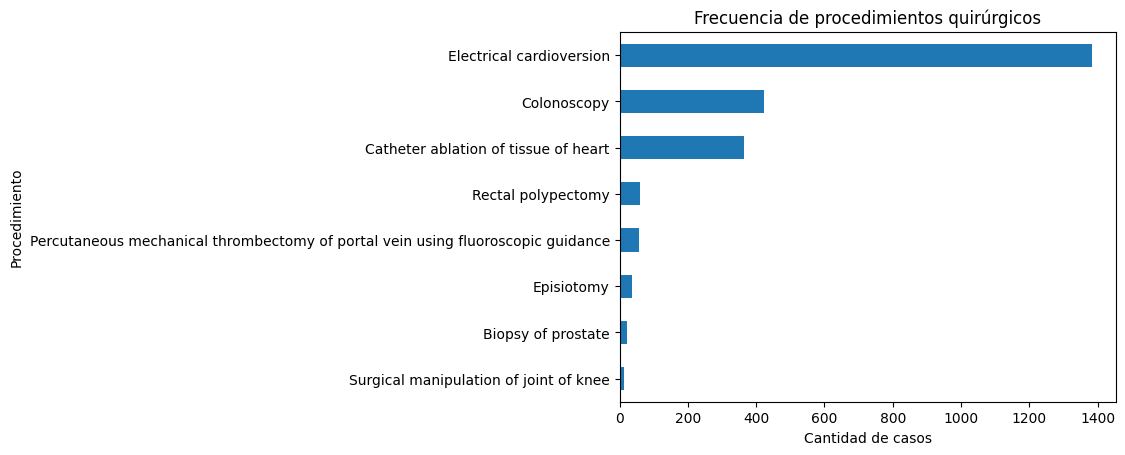

In [ ]:
# Gráfico de frecuencia de procedimientos quirúrgicos
import matplotlib.pyplot as plt

frecuencia_qx.plot(kind='barh')
plt.xlabel('Cantidad de casos')
plt.ylabel('Procedimiento')
plt.title('Frecuencia de procedimientos quirúrgicos')
plt.show()

 El gráfico muestra la heterogeneidad en la frecuencia de los procedimientos, por lo que no todos tienen el mismo peso dentro del análisis. También puede observarse que dos procedimientos clínicamente relacionados, como Colonoscopy y Rectal polypectomy, nuclean una cantidad importante de casos dentro del conjunto analizado.

In [ ]:
# Orden de la tasa de readmisión a 30 días
tasa_qx = resumen_qx_filtrado['tasa_readmision_30d'].sort_values()

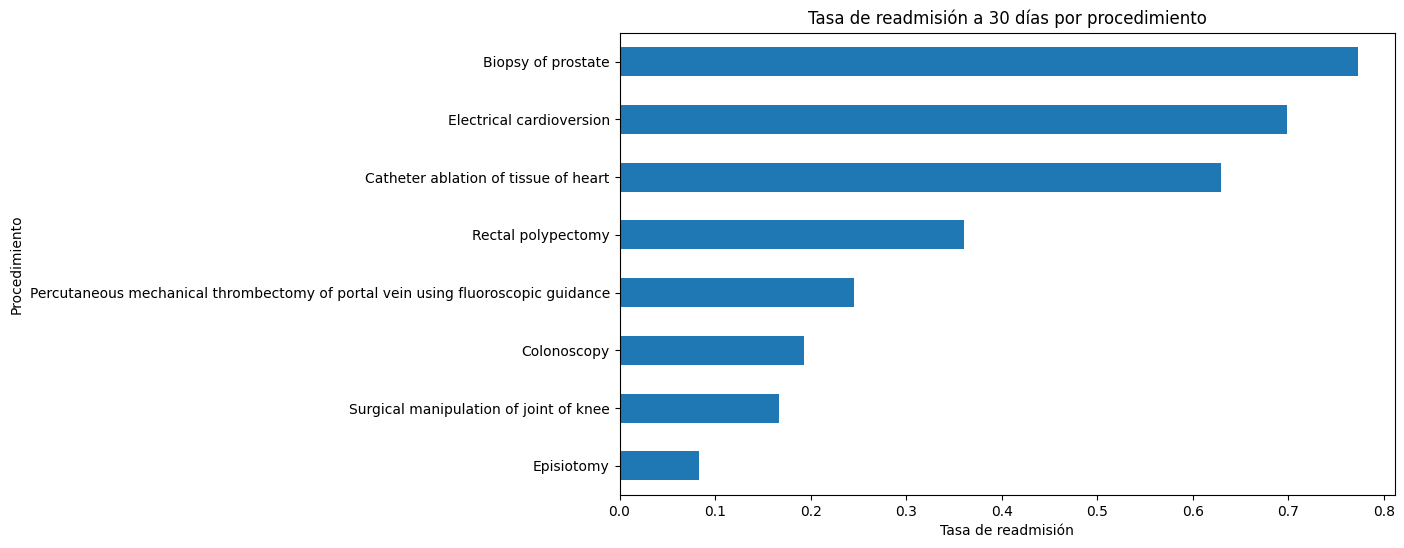

In [ ]:
# Gráfico de tasa de readmisión a 30 días
tasa_qx.plot(kind='barh', figsize=(10,6))
plt.xlabel('Tasa de readmisión')
plt.ylabel('Procedimiento')
plt.title('Tasa de readmisión a 30 días por procedimiento')
plt.show()

En este gráfico se observa un contraste importante, ya que la mayor tasa de readmisión corresponde a Biopsy of prostate. Sin embargo, también es interesante que el grupo formado por Colonoscopy y Rectal polypectomy sigue manteniendo una presencia notoria, en coincidencia con lo observado en el gráfico anterior. Esto sugiere que no se trata de procedimientos aislados dentro del análisis, sino de un conjunto con peso propio y con una relación clínica real.

In [ ]:
# Orden del costo promedio por procedimiento quirúrgico
costo_qx = resumen_qx_filtrado['costo_promedio'].sort_values()

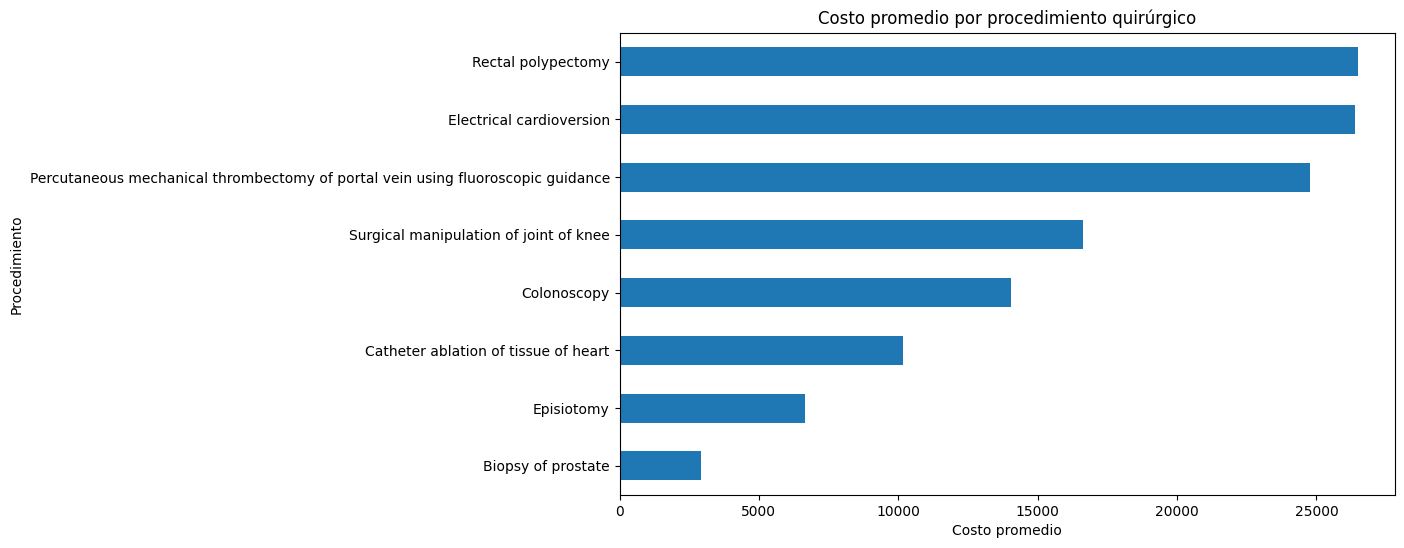

In [ ]:
# Gráfico de costo promedio por procedimiento quirúrgico
costo_qx.plot(kind='barh', figsize=(10,6))
plt.xlabel('Costo promedio')
plt.ylabel('Procedimiento')
plt.title('Costo promedio por procedimiento quirúrgico')
plt.show()

En este gráfico se observa que Rectal polypectomy presenta el mayor costo promedio, mientras que Colonoscopy también mantiene un valor elevado. Si ambos procedimientos se consideran en conjunto, su peso económico adquiere un lugar preponderante frente al resto. Esto refuerza la idea de que no se trata de hallazgos aislados, sino de un grupo de procedimientos clínicamente relacionados con peso propio dentro del análisis. Esta correlacion es sumamamnete interesante ya que ambos procedimientos comparten habitualmente protocolos tanto medicos, como de gestion asi como recursos  materiales y de personal.

## Tabla final de resultados y cierre del análisis

In [ ]:
# Tabla final ordenada por cantidad de casos
tabla_final = resumen_qx_filtrado.sort_values(by='total_casos', ascending=False)

In [ ]:
# Vista de la tabla final
tabla_final

,total_casos,readmisiones_30d,tasa_readmision_30d,costo_promedio
DESCRIPTION,,,,
Electrical cardioversion,1383,967,0.699205,26366.099335
Colonoscopy,424,82,0.193396,14058.071792
Catheter ablation of tissue of heart,365,230,0.630137,10182.001479
Rectal polypectomy,61,22,0.360656,26477.029672
Percutaneous mechanical thrombectomy of portal vein using fluoroscopic guidance,57,14,0.245614,24775.404386
Episiotomy,36,3,0.083333,6652.815000
Biopsy of prostate,22,17,0.772727,2910.282727
Surgical manipulation of joint of knee,12,2,0.166667,16630.675833


La tabla final permite identificar los procedimientos con mayor influencia en los costos de gestión y en la utilización de recursos dentro del trabajo. A su vez, puede observarse una división clara y concreta en dos grupos bien definidos: los procedimientos cardíacos y los gastroenterológicos. Esta diferenciación no solo resulta relevante por sus valores en terminos de volumen, readmisión y costo, sino que identifica dos subgrupos con características operativas, procedimentales y protocolares propias de cada grupo, lo que abre un campo de análisis muy interesante para la interpretación final de los resultados.

In [ ]:
# Redondeo de valores numéricos de la tabla final
tabla_final['tasa_readmision_30d'] = tabla_final['tasa_readmision_30d'].round(3)
tabla_final['costo_promedio'] = tabla_final['costo_promedio'].round(2)

In [ ]:
# Vista final de la tabla de resultados
tabla_final

,total_casos,readmisiones_30d,tasa_readmision_30d,costo_promedio
DESCRIPTION,,,,
Electrical cardioversion,1383,967,0.699,26366.10
Colonoscopy,424,82,0.193,14058.07
Catheter ablation of tissue of heart,365,230,0.630,10182.00
Rectal polypectomy,61,22,0.361,26477.03
Percutaneous mechanical thrombectomy of portal vein using fluoroscopic guidance,57,14,0.246,24775.40
Episiotomy,36,3,0.083,6652.82
Biopsy of prostate,22,17,0.773,2910.28
Surgical manipulation of joint of knee,12,2,0.167,16630.68


In [ ]:
# Exportación de la tabla final a CSV
tabla_final.to_csv('/content/drive/MyDrive/tabla_final_resultados.csv')

In [ ]:
# Verificación del archivo exportado en Google Drive
import os
os.path.exists('/content/drive/MyDrive/tabla_final_resultados.csv')

True

## Importancia de los halllazgos

En este analsiis pueden observarse diferencias entre costos y en readmisiones a 30 dias segun el tipo de procedimientos ,esto sugiere que el iimpacto en costos de las readmisiones no depende solo del volumen de pacientessino de las caracteristicas propias de cada practica.
El halllazgo de un volumen no esperado an dos procedimientos fuertemente vinculados como el de procedimientos Gastroenterologicos genera la necesidad de un analisis de particular con mayor nivel de precision y profundidad.

## Dashboard en Power BI